In [ ]:
# ******** PROJECT 2 - FRAUD DETECTION (CLASSIFICATION WITH REAL DATA) ********

# Core
import numpy as np
import pandas as pd
import seaborn as sns


# Viz
import matplotlib.pyplot as plt

# ML
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier


from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42


In [ ]:
pip install catboost

In [ ]:
#Step 1: Load the Data
#The IEEE-CIS dataset is split into transactions + identity tables. We merge on TransactionID.

import pandas as pd
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


# Load CSVs
train_tx = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/train_transaction.csv')
train_id = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/train_identity.csv')

# Merge (LEFT JOIN as instructed)
df = train_tx.merge(train_id, on='TransactionID', how='left')
print("Merged shape:", df.shape)

#Target
TARGET = "isFraud"
assert TARGET in df.columns


Mounted at /content/drive
Merged shape: (590540, 434)


In [ ]:
#Why merge? Identity features (device/browser/user signals) can be predictive; many rows won’t have identity data, so we use a left join to keep all transactions

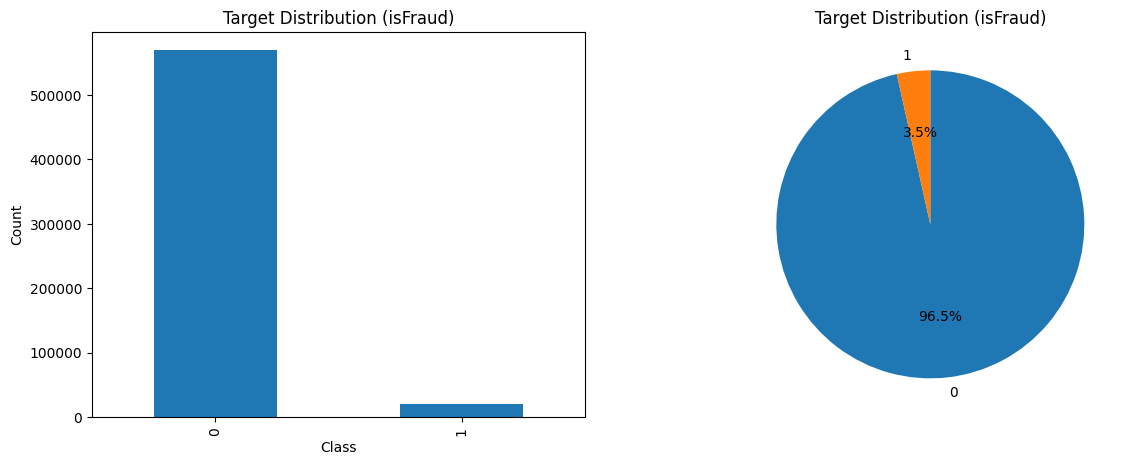

,Count,Rate
isFraud,,
0,569877,0.965
1,20663,0.035


In [ ]:
#Step 2: Exploratory Data Analysis (EDA)
#This helps to examine imbalance, relationships, correlations, missingness, and anomalies.

from IPython.display import display
import matplotlib.pyplot as plt

y = df[TARGET]
counts = y.value_counts()
rates = y.value_counts(normalize=True)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# ---------- BAR ----------
plt.sca(axes[0])
counts.plot(kind="bar")
plt.title("Target Distribution (isFraud)")
plt.xlabel("Class")
plt.ylabel("Count")

# ---------- PIE ----------
plt.sca(axes[1])
counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False
)
plt.title("Target Distribution (isFraud)")
plt.ylabel("")

#plt.tight_layout()
plt.show()

# ---------- COUNTS & RATES TABLE ----------
summary_df = pd.DataFrame({
    "Count": counts,
    "Rate": rates.round(4)
})

display(summary_df)

In [ ]:
#Fraud is rare → accuracy alone is misleading. That’s why the project requires precision/recall/F1/AUC and confusion matrix.

In [ ]:
#Numerical & Categorical Coloumns

X = df.drop(columns=['isFraud', 'TransactionID'])
y = df['isFraud']

num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns
print ("Numerical_Columns:\n", num_cols, "\n num_cols: ", len(num_cols))
print ("Categorical_Coloumns:\n", cat_cols, "\n cat_cols: ", len(cat_cols))

Numerical_Columns:
 Index(['TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3', 'card5',
       'addr1', 'addr2', 'dist1', 'dist2',
       ...
       'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_24', 'id_25',
       'id_26', 'id_32'],
      dtype='object', length=401) 
 num_cols:  401
Categorical_Coloumns:
 Index(['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1',
       'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15',
       'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33',
       'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType',
       'DeviceInfo'],
      dtype='object') 
 cat_cols:  31


In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=train, x="isFraud", y="TransactionAmt")

plt.title("Transaction Amount by Fraud class", fontsize=14)
plt.xlabel("Fraud class (0: Non-Fraud, 1: Fraud)")
plt.ylabel("Transaction Amount")
plt.show()

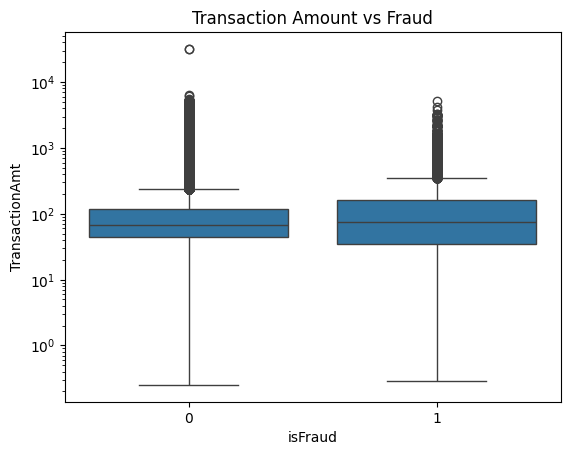

isFraud,0,1
ProductCD,,
C,0.883127,0.116873
H,0.952338,0.047662
R,0.962174,0.037826
S,0.941004,0.058996
W,0.979601,0.020399


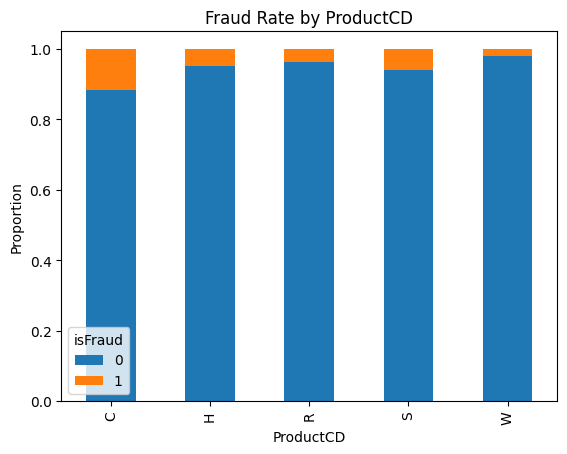

In [ ]:
#Relationship examples (numeric vs class, categorical vs class)
#Pick a few meaningful columns that exist in this dataset (these usually do): TransactionAmt, card4, ProductCD, P_emaildomain.

# Numeric vs class (example: TransactionAmt)
if "TransactionAmt" in df.columns:
    plot_df = df[['TransactionAmt']].copy()
    plot_df['isFraud'] = y.values

    sns.boxplot(x='isFraud', y='TransactionAmt', data=plot_df)
    plt.yscale('log')
    plt.title("Transaction Amount vs Fraud")
    plt.show()

# Categorical vs class (example: ProductCD)
if "ProductCD" in df.columns:
    ctab = pd.crosstab(df["ProductCD"], df[TARGET], normalize="index")
    display(ctab)

    ctab.plot(kind="bar", stacked=True)
    plt.title("Fraud Rate by ProductCD")
    plt.ylabel("Proportion")
    plt.show()


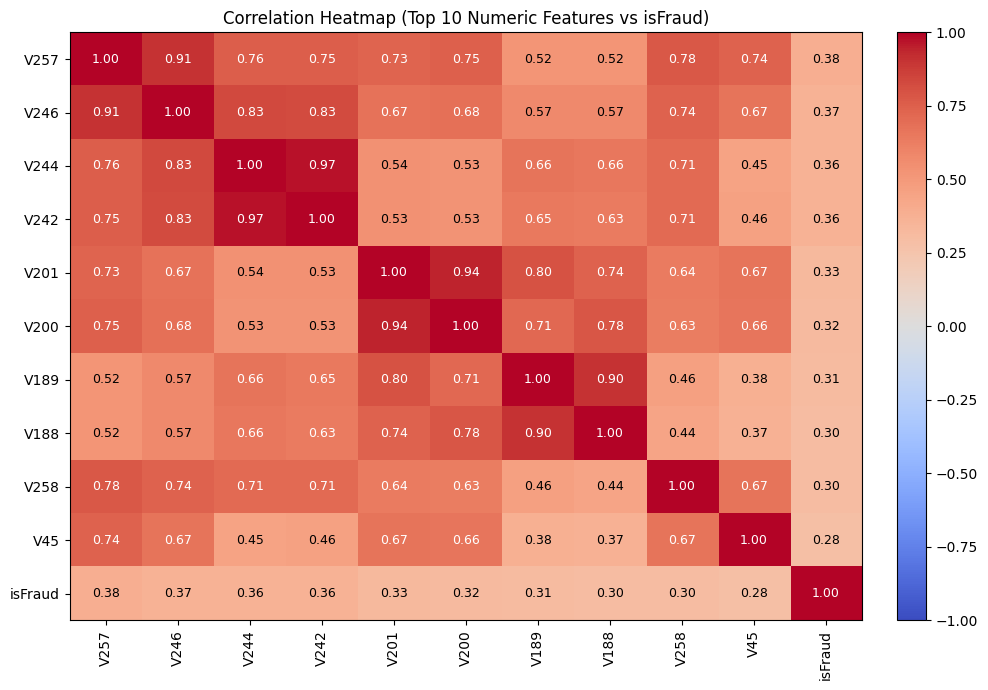

In [ ]:
# Correlation matrix with Numeric variables

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

import warnings
warnings.filterwarnings("ignore")

train_tx = "/content/drive/MyDrive/Colab Notebooks/train_transaction.csv"
TARGET = "isFraud"

df_sample = pd.read_csv(train_tx, nrows=80000, low_memory=False)

num_cols = df_sample.select_dtypes(include=[np.number]).columns.tolist()
num_cols_no_target = [c for c in num_cols if c != TARGET]

corr_with_target = df[num_cols_no_target + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET)

topn = 10
top_features = corr_with_target.abs().sort_values(ascending=False).head(topn).index.tolist()
heat_cols = top_features + [TARGET]

corr_matrix = df[heat_cols].corr(numeric_only=True)

# Normalize from -1 to +1 (true correlation scale)
norm = colors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
plt.figure(figsize=(10,7))
im = plt.imshow(corr_matrix.values, norm=norm, cmap="coolwarm", aspect="auto")
plt.colorbar(im, fraction=0.046, pad=0.04)

plt.xticks(range(len(heat_cols)), heat_cols, rotation=90)
plt.yticks(range(len(heat_cols)), heat_cols)

for i in range(len(heat_cols)):
    for j in range(len(heat_cols)):
        value = corr_matrix.values[i, j]
        plt.text(j, i, f"{value:.2f}",
                 ha="center", va="center",
                 color="black" if abs(value) < 0.6 else "white",
                 fontsize=9)

plt.title("Correlation Heatmap (Top 10 Numeric Features vs isFraud)")
plt.tight_layout()
plt.show()


Top 20 columns by missing rate:


,0
id_24,0.991962
id_25,0.991310
id_07,0.991271
id_08,0.991271
id_21,0.991264
id_26,0.991257
id_27,0.991247
id_23,0.991247
id_22,0.991247
dist2,0.936284


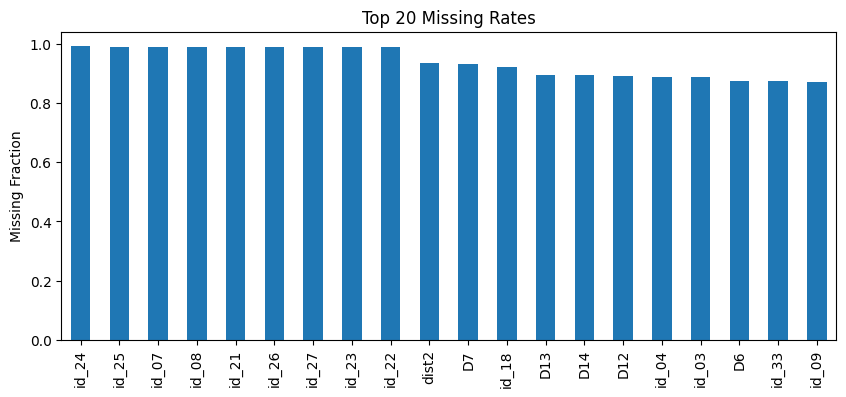

In [ ]:
#Missing values overview

missing_rate = df.isna().mean().sort_values(ascending=False)
print("Top 20 columns by missing rate:")
display(missing_rate.head(20))

plt.figure(figsize=(10,4))
missing_rate.head(20).plot(kind="bar")
plt.title("Top 20 Missing Rates")
plt.ylabel("Missing Fraction")
plt.show()

In [ ]:
#Many features have high missing rates, so we must impute and/or drop extreme-missing columns.

In [ ]:
#Drop extremely-missing columns

MISSING_DROP_THRESHOLD = 0.90  # drop columns missing > 90%
missing_rate_X = X.isna().mean()
drop_cols = missing_rate_X[missing_rate_X > MISSING_DROP_THRESHOLD].index.tolist()

print("Dropping columns:", len(drop_cols))
X = X.drop(columns=drop_cols)

# Recompute column lists after dropping
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

#Why: Columns that are almost always empty often add noise and slow down one-hot encoding.

Dropping columns: 12


In [ ]:
#Separate numeric vs categorical

X = df.drop(columns=[TARGET])

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

Numeric columns: 402
Categorical columns: 31


In [ ]:
# Step 3 Build the Data preprocessing pipeline

# Numeric: median imputation + scaling
# Categorical: most-frequent imputation + one-hot encoding
# (Scaling helps logistic regression converge and improves runtime.)
# Project requirements: handle missing values, encode categoricals, scale numeric, imbalance handling, and train/test split with stratification.


In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))  # safe with sparse output
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ],
    remainder="drop"
)

In [ ]:
#Train/test split (stratified)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(X_train.shape, X_test.shape)
print("Train fraud rate:", y_train.mean())
print("Test fraud rate:", y_test.mean())

# Why stratify: keeps the fraud rate similar in train and test.

(472432, 433) (118108, 433)
Train fraud rate: 0.03498916246147594
Test fraud rate: 0.0349933958749619


In [ ]:
# Step 4 Model Building (Baseline + Additional Models)

# Baseline: Logistic Regression

# Use class_weight="balanced" for imbalance, and a solver that works well with large sparse one-hot matrices (saga is a good choice).

In [ ]:
# Logistic Regression

log_model = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        solver="saga",
        class_weight="balanced",
        n_jobs=-1
    ))
])

log_model.fit(X_train, y_train)
cb_pred = log_model.predict(X_test)
cb_proba = log_model.predict_proba(X_test)[:,1]

In [ ]:
# Decision Trees

dt_model = Pipeline([
    ("prep", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        max_depth=10  # start reasonable to reduce overfitting
    ))
])

dt_model.fit(X_train, y_train)
cb_pred = dt_model.predict(X_test)
cb_proba = dt_model.predict_proba(X_test)[:,1]

In [ ]:
# RandomForestClassifier

rf_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=150,
        random_state=RANDOM_STATE,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        n_jobs=-1,
        max_depth=20
    ))
])

rf_model.fit(X_train, y_train)
cb_pred = rf_model.predict(X_test)
cb_proba = rf_model.predict_proba(X_test)[:,1]


In [ ]:
# XGBClassifier

xgb_model = Pipeline([
    ('prep', preprocessor),
    ('model', XGBClassifier(
        max_depth=6,
        learning_rate=0.05,
        n_estimators=400,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        eval_metric="logloss",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:,1]

In [ ]:
# CatBoostClassifier

cb_model = Pipeline([
    ("prep", preprocessor),
    ("model", CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        auto_class_weights="Balanced",     # replaces class_weights
        iterations=600,                    # lower for speed
        depth=6,                           # much faster than 10
        learning_rate=0.10,                # faster convergence
        random_seed=42,
        verbose=200,
        allow_writing_files=False
    ))
])

cb_model.fit(X_train, y_train);
cb_pred = cb_model.predict(X_test)
cb_proba = cb_model.predict_proba(X_test)[:,1]


0:	total: 191ms	remaining: 1m 54s
200:	total: 27.5s	remaining: 54.5s
400:	total: 53.7s	remaining: 26.6s
599:	total: 1m 19s	remaining: 0us


In [ ]:
# Dummy Transaction Prediction
# Project asks for at least one dummy transaction and predicted class.
# Use a real row as a “dummy example”
# This guarantees all required columns exist and avoids “missing columns” errors.
dummy = X_test.iloc[[0]].copy()  # keep as DataFrame

dummy_pred = rf_model.predict(dummy)[0]
dummy_proba = rf_model.predict_proba(dummy)[0, 1]

print("Dummy predicted class:", "Fraud" if dummy_pred == 1 else "Not Fraud")
print("Dummy fraud probability:", round(float(dummy_proba), 4))


Dummy predicted class: Not Fraud
Dummy fraud probability: 0.0987


In [ ]:
# Using RandomizedSearch which tries only a fixed number of combos instead of GridSearch which tries every combination.

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

xgb_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", XGBClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced_subsample",
        n_jobs=-1
    ))
])

param_dist = {
    "model__n_estimators": randint(150, 250),
    "model__max_depth": [15, 25],
    "model__min_samples_leaf": randint(2, 5),
    "model__max_features": ["sqrt"]
}

rand_search = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1",
    cv=2,
    n_jobs=1,
    verbose=2,
    random_state=RANDOM_STATE
)

rand_search.fit(X_train, y_train)
best_xgb = rand_search.best_estimator_
print("Best params:", rand_search.best_params_)

Fitting 2 folds for each of 10 candidates, totalling 20 fits
[CV] END model__max_depth=15, model__max_features=sqrt, model__min_samples_leaf=2, model__n_estimators=164; total time=  34.0s
[CV] END model__max_depth=15, model__max_features=sqrt, model__min_samples_leaf=2, model__n_estimators=164; total time=  34.4s
[CV] END model__max_depth=15, model__max_features=sqrt, model__min_samples_leaf=2, model__n_estimators=170; total time=  33.2s
[CV] END model__max_depth=15, model__max_features=sqrt, model__min_samples_leaf=2, model__n_estimators=170; total time=  32.6s
[CV] END model__max_depth=15, model__max_features=sqrt, model__min_samples_leaf=3, model__n_estimators=232; total time=  36.8s
[CV] END model__max_depth=15, model__max_features=sqrt, model__min_samples_leaf=3, model__n_estimators=232; total time=  38.4s
[CV] END model__max_depth=15, model__max_features=sqrt, model__min_samples_leaf=4, model__n_estimators=224; total time=  37.7s
[CV] END model__max_depth=15, model__max_features=

In [ ]:
# Step 5 Model Evaluation
# Project requires: Accuracy, Precision, Recall, F1, AUC-ROC, TPR, TNR, Confusion Matrix, plus model comparison and discussion.

In [ ]:
Xt_train = log_model.named_steps["prep"].transform(X_train)
Xt_test  = log_model.named_steps["prep"].transform(X_test)

print("Encoded train features:", Xt_train.shape[1])
print("Encoded test features :", Xt_test.shape[1])

Encoded train features: 2689
Encoded test features : 2689


In [ ]:
# Helper function (metrics + confusion matrix + ROC)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score
)

def evaluate_model(model, X_test, y_test, name="model"):
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()

    precision = precision_score(y_test, pred, zero_division=0)
    recall = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)
    acc = (tp + tn) / (tp + tn + fp + fn)

    # Specificity (TNR)
    tnr = tn / (tn + fp) if (tn + fp) else 0

    auc = roc_auc_score(y_test, proba) if proba is not None else np.nan

    results = {
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall (TPR)": recall,
        "F1": f1,
        "TNR (Specificity)": tnr,
        "AUC-ROC": auc,
        "TN": tn, "FP": fp, "FN": fn, "TP": tp
    }

    print("="*70)
    print(name)
    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(y_test, pred, zero_division=0))
    print("Metrics:", {k: round(v, 4) if isinstance(v, float) else v for k, v in results.items()})

    # Return ROC curve data (but DO NOT plot here)
    if proba is not None:
        fpr, tpr_curve, _ = roc_curve(y_test, proba)
        results["roc_fpr"] = fpr
        results["roc_tpr"] = tpr_curve

    return results

Logistic Regression
Confusion Matrix:
 [[95261 18714]
 [ 1107  3026]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.84      0.91    113975
           1       0.14      0.73      0.23      4133

    accuracy                           0.83    118108
   macro avg       0.56      0.78      0.57    118108
weighted avg       0.96      0.83      0.88    118108

Metrics: {'Model': 'Logistic Regression', 'Accuracy': np.float64(0.8322), 'Precision': 0.1392, 'Recall (TPR)': 0.7322, 'F1': 0.2339, 'TNR (Specificity)': np.float64(0.8358), 'AUC-ROC': np.float64(0.8672), 'TN': np.int64(95261), 'FP': np.int64(18714), 'FN': np.int64(1107), 'TP': np.int64(3026)}
Decision Tree
Confusion Matrix:
 [[98836 15139]
 [ 1106  3027]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.87      0.92    113975
           1       0.17      0.73      0.27      4133

    accuracy                  

,Model,Accuracy,Precision,Recall (TPR),F1,TNR (Specificity),AUC-ROC,TN,FP,FN,TP
3,XGBoost,0.979612,0.918486,0.458021,0.611237,0.998526,0.933778,113807,168,2240,1893
2,Random Forest,0.947667,0.365933,0.676264,0.474896,0.957508,0.915854,109132,4843,1338,2795
4,CatBoost,0.914790,0.268411,0.831599,0.405833,0.917807,0.947202,104607,9368,696,3437
1,Decision Tree,0.862456,0.166630,0.732398,0.271492,0.867173,0.867347,98836,15139,1106,3027
0,Logistic Regression,0.832179,0.139190,0.732156,0.233912,0.835806,0.867211,95261,18714,1107,3026


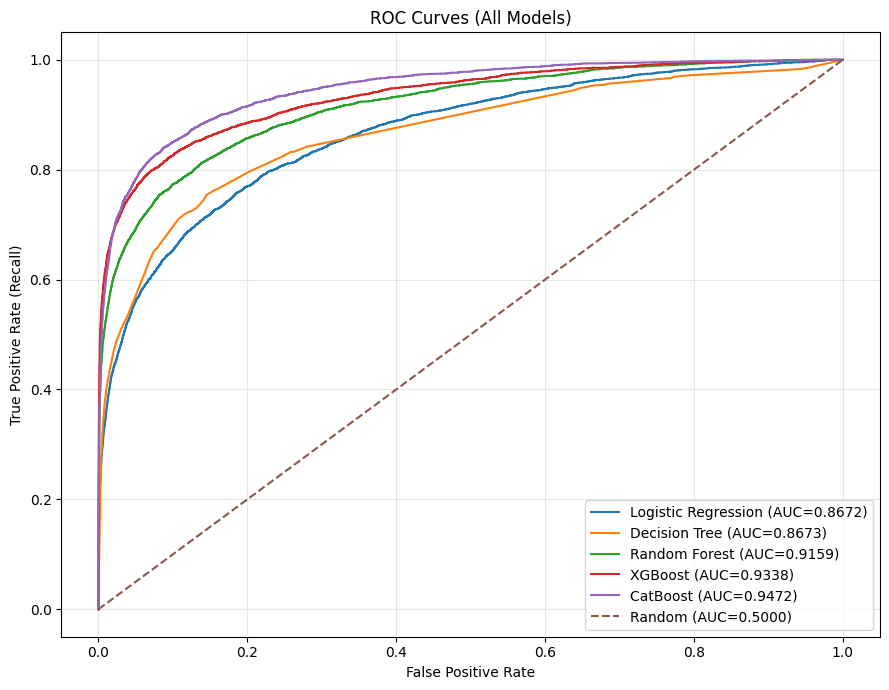

In [ ]:
results = []
results.append(evaluate_model(log_model, X_test, y_test, "Logistic Regression"))
results.append(evaluate_model(dt_model,  X_test, y_test, "Decision Tree"))
results.append(evaluate_model(rf_model,  X_test, y_test, "Random Forest"))
results.append(evaluate_model(xgb_model, X_test, y_test, "XGBoost"))
results.append(evaluate_model(cb_model,  X_test, y_test, "CatBoost"))

results_df = pd.DataFrame(results)

# Remove ROC curve arrays from display
results_df = results_df.drop(columns=["roc_fpr", "roc_tpr"], errors="ignore")

results_df = results_df.sort_values(by="F1", ascending=False)
display(results_df)

#results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)
#display(results_df)

# ---- ONE combined ROC plot ----
plt.figure(figsize=(9, 7))

for r in results:
    if "roc_fpr" in r and "roc_tpr" in r:
        plt.plot(r["roc_fpr"], r["roc_tpr"], label=f'{r["Model"]} (AUC={r["AUC-ROC"]:.4f})')
    else:
        print(f'Skipping ROC for {r["Model"]}: no predict_proba.')

# baseline
plt.plot([0, 1], [0, 1], linestyle="--", label="Random (AUC=0.5000)")

plt.title("ROC Curves (All Models)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Evaluation of overfitting or underfitting

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

def evaluate_train_test(model, X_train, y_train, X_test, y_test, name="model"):
    # ---- Train predictions ----
    yhat_tr = model.predict(X_train)
    proba_tr = model.predict_proba(X_train)[:, 1] if hasattr(model, "predict_proba") else None

    # ---- Test predictions ----
    yhat_te = model.predict(X_test)
    proba_te = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    # ---- Metrics (Train) ----
    train_acc = accuracy_score(y_train, yhat_tr)
    train_prec = precision_score(y_train, yhat_tr, zero_division=0)
    train_rec = recall_score(y_train, yhat_tr, zero_division=0)
    train_f1 = f1_score(y_train, yhat_tr, zero_division=0)
    train_auc = roc_auc_score(y_train, proba_tr) if proba_tr is not None else np.nan

    # ---- Metrics (Test) ----
    test_acc = accuracy_score(y_test, yhat_te)
    test_prec = precision_score(y_test, yhat_te, zero_division=0)
    test_rec = recall_score(y_test, yhat_te, zero_division=0)
    test_f1 = f1_score(y_test, yhat_te, zero_division=0)
    test_auc = roc_auc_score(y_test, proba_te) if proba_te is not None else np.nan

    # ---- Gap (Overfit indicator) ----
    f1_gap = train_f1 - test_f1
    auc_gap = train_auc - test_auc

    # ---- Confusion Matrix (Test) ----
    tn, fp, fn, tp = confusion_matrix(y_test, yhat_te).ravel()
    tpr = tp / (tp + fn) if (tp + fn) else 0.0
    tnr = tn / (tn + fp) if (tn + fp) else 0.0

    # ---- Simple diagnosis ----
    # adjust thresholds if you want, but these work well for a class project
    if (f1_gap > 0.15) or (auc_gap > 0.10):
        diagnosis = "Likely OVERFITTING (train >> test)"
    elif (train_f1 < 0.10 and test_f1 < 0.10) and (train_auc < 0.60 and test_auc < 0.60):
        diagnosis = "Likely UNDERFITTING (both low)"
    else:
        diagnosis = "Reasonable generalization"

    return {
        "Model": name,

        "Train_F1": train_f1,
        "Test_F1": test_f1,
        "F1_Gap": f1_gap,

        "Train_AUC": train_auc,
        "Test_AUC": test_auc,
        "AUC_Gap": auc_gap,

        "Test_Precision": test_prec,
        "Test_Recall": test_rec,
        "Test_Accuracy": test_acc,
        "Test_TPR": tpr,
        "Test_TNR": tnr,

        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "Diagnosis": diagnosis
    }


In [ ]:
# All models same split and same X format

results = []
results.append(evaluate_train_test(log_model, X_train, y_train, X_test, y_test, "Logistic Regression"))
results.append(evaluate_train_test(dt_model,  X_train, y_train, X_test, y_test, "Decision Tree"))
results.append(evaluate_train_test(rf_model,  X_train, y_train, X_test, y_test, "Random Forest"))
results.append(evaluate_train_test(xgb_model, X_train, y_train, X_test, y_test, "XGBoost"))
results.append(evaluate_train_test(cb_model,  X_train, y_train, X_test, y_test, "CatBoost"))

results_df = pd.DataFrame(results).sort_values(by="Test_F1", ascending=False)
display(results_df)

,Model,Train_F1,Test_F1,F1_Gap,Train_AUC,Test_AUC,AUC_Gap,Test_Precision,Test_Recall,Test_Accuracy,Test_TPR,Test_TNR,TN,FP,FN,TP,Diagnosis
3,XGBoost,0.647527,0.611237,0.036291,0.947756,0.933778,0.013978,0.918486,0.458021,0.979612,0.458021,0.998526,113807,168,2240,1893,Reasonable generalization
2,Random Forest,0.560593,0.474896,0.085697,0.956091,0.915854,0.040237,0.365933,0.676264,0.947667,0.676264,0.957508,109132,4843,1338,2795,Reasonable generalization
4,CatBoost,0.427976,0.405833,0.022143,0.965152,0.947202,0.017950,0.268411,0.831599,0.914790,0.831599,0.917807,104607,9368,696,3437,Reasonable generalization
1,Decision Tree,0.284486,0.271492,0.012994,0.888737,0.867347,0.021390,0.166630,0.732398,0.862456,0.732398,0.867173,98836,15139,1106,3027,Reasonable generalization
0,Logistic Regression,0.235943,0.233903,0.002040,0.869562,0.867212,0.002350,0.139184,0.732156,0.832171,0.732156,0.835797,95260,18715,1107,3026,Reasonable generalization


In [ ]:
# Precision-Recall trade-offs

import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

def pr_table_xgb(model, X_test, y_test):
    proba = model.predict_proba(X_test)[:,1]
    rows = []
    for t in np.arange(0.05, 0.95, 0.05):
        pred = (proba >= t).astype(int)
        rows.append({
            "Threshold": round(t,2),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0),
            "F1": f1_score(y_test, pred, zero_division=0),
            "Fraud_Flag_Rate": pred.mean()
        })
    return pd.DataFrame(rows)

pr_df = pr_table_xgb(xgb_model, X_test, y_test)
pr_df


,Threshold,Precision,Recall,F1,Fraud_Flag_Rate
0,0.05,0.282288,0.800145,0.417340,0.099189
1,0.10,0.485804,0.712074,0.577568,0.051292
2,0.15,0.623022,0.657392,0.639746,0.036924
3,0.20,0.721526,0.613114,0.662917,0.029735
4,0.25,0.785951,0.573917,0.663404,0.025553
5,0.30,0.835177,0.548028,0.661797,0.022962
6,0.35,0.866480,0.522865,0.652180,0.021116
7,0.40,0.893900,0.503508,0.644173,0.019711
8,0.45,0.908509,0.480523,0.628580,0.018508
9,0.50,0.918486,0.458021,0.611237,0.017450


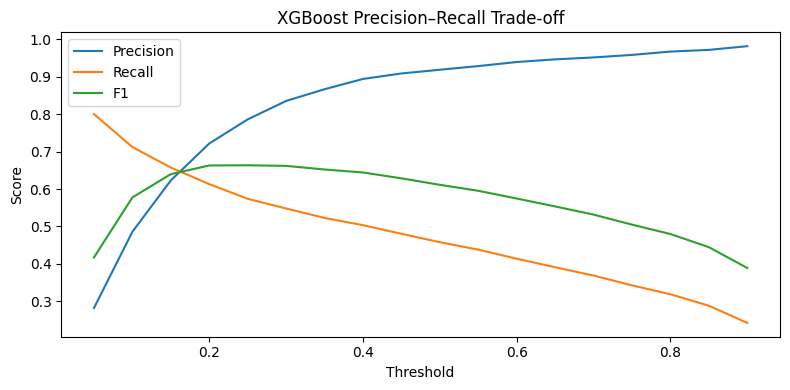

In [ ]:
# Visual trade-off curve

plt.figure(figsize=(8,4))
plt.plot(pr_df["Threshold"], pr_df["Precision"], label="Precision")
plt.plot(pr_df["Threshold"], pr_df["Recall"], label="Recall")
plt.plot(pr_df["Threshold"], pr_df["F1"], label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("XGBoost Precision–Recall Trade-off")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Selected Operating Threshold = 0.25
# The default classification threshold of 0.50 was lowered to 0.25 to improve fraud detection sensitivity.
# Lowering the threshold increases recall, meaning more fraudulent transactions are detected, which is critical in financial fraud systems where the cost of missing fraud is high.

proba = xgb_model.predict_proba(X_test)[:,1]
xgb_final_pred = (proba >= 0.25).astype(int)

In [ ]:
# XGBoost model performance at threshold = 0.25

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, xgb_final_pred, zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test, xgb_final_pred))


              precision    recall  f1-score   support

           0       0.98      0.99      0.99    113975
           1       0.79      0.57      0.66      4133

    accuracy                           0.98    118108
   macro avg       0.89      0.78      0.83    118108
weighted avg       0.98      0.98      0.98    118108

Confusion Matrix:
 [[113329    646]
 [  1761   2372]]


In [ ]:
# Discussion points:

#Accuracy may look high even for weak models because fraud is rare.

#If Recall is low → too many frauds missed (FN high).

#If Precision is low → too many customers falsely flagged (FP high).

#AUC gives a threshold-independent view of ranking quality.

In [ ]:
# Get final feature names after preprocessing
# Because we use OneHotEncoder, the model “features” are expanded. We must extract the post-transform column names.

import numpy as np
import pandas as pd

def get_feature_names_from_preprocessor(preprocessor, num_cols, cat_cols):
    """
    Returns the final feature names after ColumnTransformer (num + onehot cat).
    Works for pipelines like:
      - num: imputer + scaler
      - cat: imputer + OneHotEncoder
    """
    # numeric names stay the same
    num_features = list(num_cols)

    # categorical one-hot names
    ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    cat_features = ohe.get_feature_names_out(cat_cols).tolist()

    return num_features + cat_features

# Example usage:
feature_names = get_feature_names_from_preprocessor(preprocessor, num_cols, cat_cols)
print("Number of transformed features:", len(feature_names))

Number of transformed features: 2689


In [ ]:
# Feature Importance
# Project asks for top features and interpretation.
# Get feature names after preprocessing
# Positive coefficient → increases predicted probability of fraud
# Negative coefficient → decreases probability of fraud

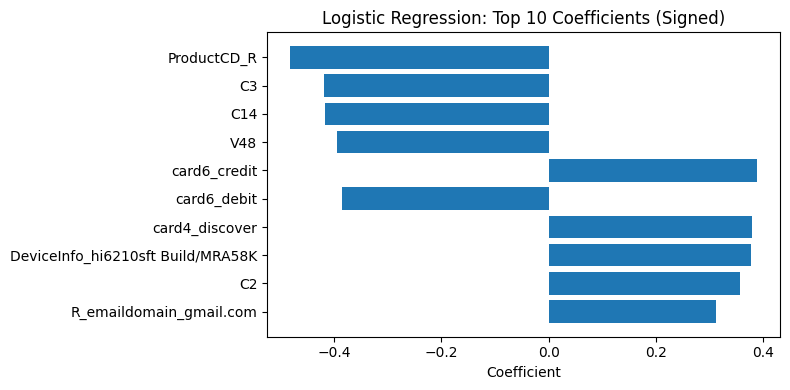

,feature,coef,abs_coef
394,ProductCD_R,-0.481167,0.481167
12,C3,-0.418466,0.418466
23,C14,-0.416752,0.416752
85,V48,-0.393839,0.393839
402,card6_credit,0.387355,0.387355
403,card6_debit,-0.384652,0.384652
398,card4_discover,0.378017,0.378017
2632,DeviceInfo_hi6210sft Build/MRA58K,0.376517,0.376517
11,C2,0.356711,0.356711
480,R_emaildomain_gmail.com,0.311735,0.311735


In [ ]:
# Logistic Regression feature importance (coefficients)

import matplotlib.pyplot as plt

def plot_logreg_coefficients(log_model, feature_names, top_n=10):
    lr = log_model.named_steps["model"]
    coefs = lr.coef_.ravel()

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coef": coefs,
        "abs_coef": np.abs(coefs)
    }).sort_values("abs_coef", ascending=False)

    top = coef_df.head(top_n)

    plt.figure(figsize=(8,4))
    plt.barh(top["feature"][::-1], top["coef"][::-1])
    plt.title(f"Logistic Regression: Top {top_n} Coefficients (Signed)")
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()

    return coef_df

logreg_coef_df = plot_logreg_coefficients(log_model, feature_names, top_n=10)
logreg_coef_df.head(15)


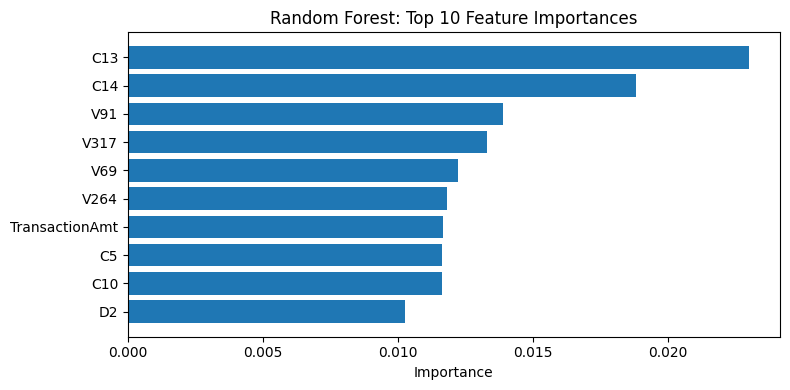

,feature,importance
22,C13,0.022986
23,C14,0.018800
128,V91,0.013871
354,V317,0.013302
106,V69,0.012231
301,V264,0.011826
2,TransactionAmt,0.011661
14,C5,0.011628
19,C10,0.011625
25,D2,0.010262


In [ ]:
# Tree-based models: analyzing feature importance

def plot_tree_importance_sklearn(pipe_model, feature_names, top_n=10, title="Tree Model"):
    model = pipe_model.named_steps["model"]
    importances = model.feature_importances_

    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

    top = imp_df.head(top_n)

    plt.figure(figsize=(8,4))
    plt.barh(top["feature"][::-1], top["importance"][::-1])
    plt.title(f"{title}: Top {top_n} Feature Importances")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    return imp_df

# Random Forest feature importance (coefficients)

rf_imp_df = plot_tree_importance_sklearn(rf_model, feature_names, top_n=10, title="Random Forest")
rf_imp_df.head(15)


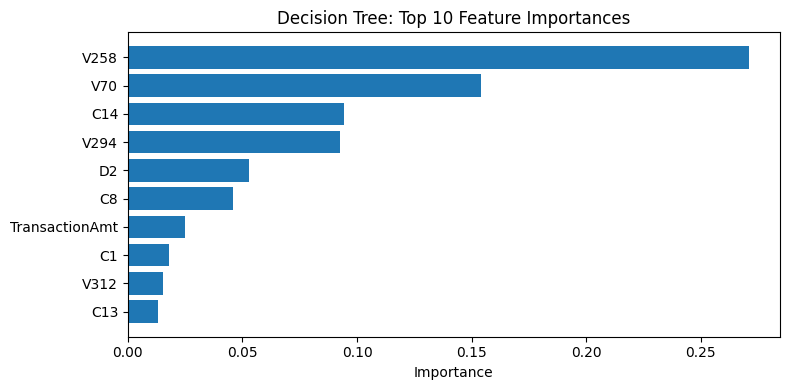

,feature,importance
295,V258,0.270983
107,V70,0.154245
23,C14,0.094162
331,V294,0.092566
25,D2,0.052779
17,C8,0.046061
2,TransactionAmt,0.024865
10,C1,0.017738
349,V312,0.015174
22,C13,0.013348


In [ ]:
# Decision Tree feature importance (coefficients)

dt_imp_df = plot_tree_importance_sklearn(dt_model, feature_names, top_n=10, title="Decision Tree")
dt_imp_df.head(15)

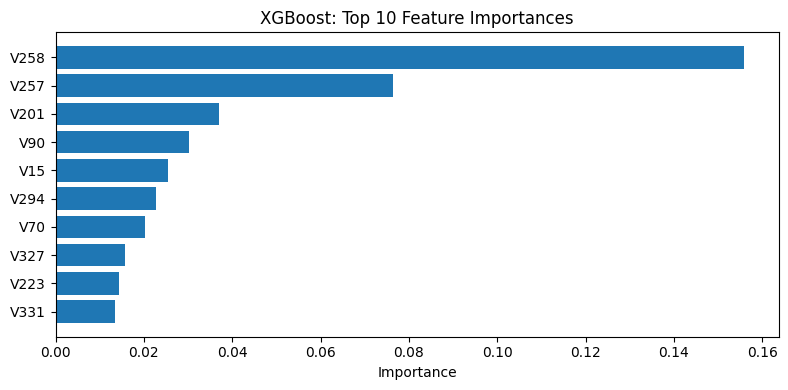

,feature,importance
295,V258,0.155998
294,V257,0.076294
238,V201,0.037024
127,V90,0.030125
52,V15,0.025421
331,V294,0.022801
107,V70,0.020281
364,V327,0.015659
260,V223,0.014454
368,V331,0.013445


In [ ]:
# XGBoost feature importance (coefficients)

xgb_imp_df = plot_tree_importance_sklearn(xgb_model, feature_names, top_n=10, title="XGBoost")
xgb_imp_df.head(15)


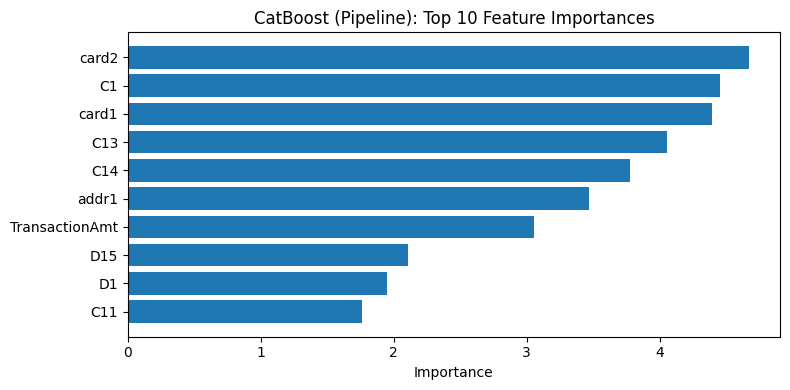

,feature,importance
4,card2,4.670779
10,C1,4.450035
3,card1,4.391850
22,C13,4.055375
23,C14,3.778011
7,addr1,3.464601
2,TransactionAmt,3.054851
37,D15,2.106246
24,D1,1.947282
20,C11,1.759724


In [ ]:
# CatBoost feature importance (coefficients)

from catboost import CatBoostClassifier

cb_est = cb_model.named_steps["model"]
cb_importances = cb_est.get_feature_importance()

cb_imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": cb_importances
}).sort_values("importance", ascending=False)

top_n = 10
top = cb_imp_df.head(top_n)

plt.figure(figsize=(8,4))
plt.barh(top["feature"][::-1], top["importance"][::-1])
plt.title(f"CatBoost (Pipeline): Top {top_n} Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

cb_imp_df.head(15)


In [ ]:
# All models consensus importance table

top_n = 10
consensus = pd.DataFrame({
    "LR_top": logreg_coef_df["feature"].head(top_n).values,
    "RF_top": rf_imp_df["feature"].head(top_n).values,
    "DT_top": dt_imp_df["feature"].head(top_n).values,
    "XGB_top": xgb_imp_df["feature"].head(top_n).values,
    "CB_top": cb_imp_df["feature"].head(top_n).values

})
consensus

,LR_top,RF_top,DT_top,XGB_top,CB_top
0,ProductCD_R,C13,V258,V258,card2
1,C3,C14,V70,V257,C1
2,C14,V91,C14,V201,card1
3,V48,V317,V294,V90,C13
4,card6_credit,V69,D2,V15,C14
5,card6_debit,V264,C8,V294,addr1
6,card4_discover,TransactionAmt,TransactionAmt,V70,TransactionAmt
7,DeviceInfo_hi6210sft Build/MRA58K,C5,C1,V327,D15
8,C2,C10,V312,V223,D1
9,R_emaildomain_gmail.com,D2,C13,V331,C11
